In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SpiritPricing") \
    .config("spark.driver.memory", "12g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

26/03/12 13:38:51 WARN Utils: Your hostname, Sarahs-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 10.2.59.121 instead (on interface en0)
26/03/12 13:38:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/12 13:38:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [2]:
# Base path
base_path = "/Users/nasaka/Documents/Cloud Computing/Market_08_17/"

# Load all quarterly files at once via wildcard
fares_raw = spark.read.csv(
    f"{base_path}/*.csv",
    header=True,
    inferSchema=True
)

print(f"Total rows: {fares_raw.count():,}")
print(f"Columns: {fares_raw.columns}")
fares_raw.show(3)

26/03/12 13:39:05 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Total rows: 182,515,370
Columns: ['ItinID', 'MktID', 'MktCoupons', 'Year', 'Quarter', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCountry', 'OriginStateFips', 'OriginState', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCountry', 'DestStateFips', 'DestState', 'DestStateName', 'DestWac', 'AirportGroup', 'WacGroup', 'TkCarrierChange', 'TkCarrierGroup', 'OpCarrierChange', 'OpCarrierGroup', 'RPCarrier', 'TkCarrier', 'OpCarrier', 'BulkFare', 'Passengers', 'MktFare', 'MktDistance', 'MktDistanceGroup', 'MktMilesFlown', 'NonStopMiles', 'ItinGeoType', 'MktGeoType', '_c41']


26/03/12 13:41:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+------------+----------+----+-------+---------------+------------------+------------------+------+-------------+---------------+-----------+---------------+---------+-------------+----------------+----------------+----+-----------+-------------+---------+--------------+-------+------------+--------+---------------+--------------+---------------+--------------+---------+---------+---------+--------+----------+-------+-----------+----------------+-------------+------------+-----------+----------+----+
|      ItinID|       MktID|MktCoupons|Year|Quarter|OriginAirportID|OriginAirportSeqID|OriginCityMarketID|Origin|OriginCountry|OriginStateFips|OriginState|OriginStateName|OriginWac|DestAirportID|DestAirportSeqID|DestCityMarketID|Dest|DestCountry|DestStateFips|DestState| DestStateName|DestWac|AirportGroup|WacGroup|TkCarrierChange|TkCarrierGroup|OpCarrierChange|OpCarrierGroup|RPCarrier|TkCarrier|OpCarrier|BulkFare|Passengers|MktFare|MktDistance|MktDistanceGroup|MktMilesFlown|NonS

26/03/12 13:41:38 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: ItinID, MktID, MktCoupons, Year, Quarter, OriginAirportID, OriginAirportSeqID, OriginCityMarketID, Origin, OriginCountry, OriginStateFips, OriginState, OriginStateName, OriginWac, DestAirportID, DestAirportSeqID, DestCityMarketID, Dest, DestCountry, DestStateFips, DestState, DestStateName, DestWac, AirportGroup, WacGroup, TkCarrierChange, TkCarrierGroup, OpCarrierChange, OpCarrierGroup, RPCarrier, TkCarrier, OpCarrier, BulkFare, Passengers, MktFare, MktDistance, MktDistanceGroup, MktMilesFlown, NonStopMiles, ItinGeoType, MktGeoType, 
 Schema: ItinID, MktID, MktCoupons, Year, Quarter, OriginAirportID, OriginAirportSeqID, OriginCityMarketID, Origin, OriginCountry, OriginStateFips, OriginState, OriginStateName, OriginWac, DestAirportID, DestAirportSeqID, DestCityMarketID, Dest, DestCountry, DestStateFips, DestState, DestStateName, DestWac, AirportGroup, WacGroup, TkCarrierChange, TkCarrierGroup, O

In [3]:
from pyspark.sql import functions as F

# Drop the phantom trailing column
fares = fares_raw.drop("_c41")

# Filter to study period and domestic only
nyc = ["JFK", "LGA", "EWR"]

fares = fares.filter(
    (F.col("Year") >= 2008) & (F.col("Year") <= 2016) &
    (F.col("OriginCountry") == "US") &
    (F.col("DestCountry") == "US") &
    (F.col("BulkFare") == 0) &           # exclude bulk/opaque fares
    (F.col("MktFare") > 25) &
    (F.col("MktFare") < 2500) &
    (F.col("Passengers") > 0) &
    (~F.col("Origin").isin(nyc)) &        # NYC exclusion
    (~F.col("Dest").isin(nyc))
)

# Build unordered city-pair route — matches full_combined.csv exactly
fares = fares.withColumn(
    "route",
    F.concat_ws("_", F.least("Origin", "Dest"), F.greatest("Origin", "Dest"))
)

# Keep only columns needed for fare analysis
fares = fares.select(
    "Year", "Quarter", "route", "Origin", "Dest",
    "OpCarrier", "MktFare", "Passengers",
    "MktDistanceGroup", "MktDistance"
)

fares.cache()
print(f"Rows after cleaning: {fares.count():,}")

# Confirm Spirit is present
fares.groupBy("OpCarrier").count().orderBy("count", ascending=False).show(10)

Rows after cleaning: 155,073,092


+---------+--------+
|OpCarrier|   count|
+---------+--------+
|       99|43920692|
|       WN|24905957|
|       DL|16187237|
|       AA|12941312|
|       UA| 9849102|
|       US| 7426188|
|       OO| 4027983|
|       FL| 3787701|
|       AS| 3067624|
|       B6| 2590351|
+---------+--------+
only showing top 10 rows



In [4]:
# Check NK specifically and drop carrier 99
print("=== Spirit rows ===")
fares.filter(F.col("OpCarrier") == "NK").count()

=== Spirit rows ===


1423275

In [5]:
# Drop codeshare placeholder and filter to only carriers in your full_combined
fares = fares.filter(
    (F.col("OpCarrier") != "99") &
    (F.col("OpCarrier") != "99.0")
)

# Confirm NK is now visible
fares.groupBy("OpCarrier").count().orderBy("count", ascending=False).show(20)

+---------+--------+
|OpCarrier|   count|
+---------+--------+
|       WN|24905957|
|       DL|16187237|
|       AA|12941312|
|       UA| 9849102|
|       US| 7426188|
|       OO| 4027983|
|       FL| 3787701|
|       AS| 3067624|
|       B6| 2590351|
|       EV| 2514309|
|       MQ| 2267644|
|       F9| 2115644|
|       CO| 1876969|
|       NW| 1592438|
|       YX| 1557617|
|       9E| 1466180|
|       NK| 1423275|
|       HA| 1283071|
|       YV| 1260430|
|       QX|  966650|
+---------+--------+
only showing top 20 rows



In [6]:
fares.groupBy("Year", "Quarter").count().orderBy("Year", "Quarter").show(40)

+----+-------+-------+
|Year|Quarter|  count|
+----+-------+-------+
|2008|      1|3077408|
|2008|      2|3666328|
|2008|      3|3053311|
|2008|      4|2998148|
|2009|      1|2563222|
|2009|      2|3039737|
|2009|      3|3087648|
|2009|      4|3325136|
|2010|      1|2962026|
|2010|      2|3468700|
|2010|      3|3263484|
|2010|      4|3468357|
|2011|      1|3318356|
|2011|      2|3563518|
|2011|      3|3507344|
|2011|      4|3487672|
|2012|      1|3267443|
|2012|      2|3557984|
|2012|      3|3431638|
|2012|      4|3513158|
|2013|      1|3225198|
|2013|      2|3683095|
|2013|      3|3453883|
|2014|      1|3297125|
|2014|      4|3878910|
|2015|      1|3450969|
|2015|      2|4065568|
|2015|      3|3966122|
|2015|      4|4021815|
|2016|      2|4189806|
|2016|      3|4095345|
|2016|      4|4203946|
+----+-------+-------+



In [7]:
# Step 1: Aggregate fares to route-quarter-carrier level
fares_agg = fares.groupBy("Year", "Quarter", "route", "OpCarrier") \
    .agg(
        F.percentile_approx("MktFare", 0.5).alias("median_fare"),
        F.mean("MktFare").alias("mean_fare"),
        F.percentile_approx("MktFare", 0.25).alias("fare_p25"),
        F.percentile_approx("MktFare", 0.75).alias("fare_p75"),
        F.sum("Passengers").alias("fare_passengers")
    )

print(f"Aggregated fare rows: {fares_agg.count():,}")
fares_agg.show(3)

Aggregated fare rows: 1,680,902


+----+-------+-------+---------+-----------+------------------+--------+--------+---------------+
|Year|Quarter|  route|OpCarrier|median_fare|         mean_fare|fare_p25|fare_p75|fare_passengers|
+----+-------+-------+---------+-----------+------------------+--------+--------+---------------+
|2008|      1|ABE_ATL|       OH|     272.99|324.56696969696975|  174.52|  423.99|           37.0|
|2008|      1|ABE_CLE|       CO|      70.55|           222.435|   70.55|  374.32|            2.0|
|2008|      1|ABE_DAY|       OO|     124.98|            123.58|   95.48|  150.28|            3.0|
+----+-------+-------+---------+-----------+------------------+--------+--------+---------------+
only showing top 3 rows



In [8]:
fares_agg.show(10)

+----+-------+-------+---------+-----------+------------------+--------+--------+---------------+
|Year|Quarter|  route|OpCarrier|median_fare|         mean_fare|fare_p25|fare_p75|fare_passengers|
+----+-------+-------+---------+-----------+------------------+--------+--------+---------------+
|2008|      1|ABE_ATL|       OH|     272.99|324.56696969696975|  174.52|  423.99|           37.0|
|2008|      1|ABE_CLE|       CO|      70.55|           222.435|   70.55|  374.32|            2.0|
|2008|      1|ABE_DAY|       OO|     124.98|            123.58|   95.48|  150.28|            3.0|
|2008|      1|ABE_GNV|       16|     165.47|            165.47|  165.47|  165.47|            2.0|
|2008|      1|ABE_GSP|       EV|     273.53|           407.755|  273.53|  541.98|            2.0|
|2008|      1|ABE_LIH|       US|     399.88|            399.88|  399.88|  399.88|            1.0|
|2008|      1|ABE_MCI|       XE|     136.67|            136.67|  136.67|  136.67|            1.0|
|2008|      1|ABE_OA

In [ ]:
# Step 2: Load full_combined.csv
combined_path = "Users/nasaka/Documents/Cloud Computing/full_combined.csv"

df = spark.read.csv(combined_path, header=True, inferSchema=True)
df = df.filter(
    (F.col("Year") >= 2008) & (F.col("Year") <= 2016)
)
df.cache()
print(f"full_combined rows (2008-2016): {df.count():,}")

In [ ]:
# Step 3: Join fares onto full_combined
df_with_fares = df.join(
    fares_agg,
    on=["Year", "Quarter", "route", "OpCarrier"],
    how="left"
)

df_with_fares.cache()

# Check match rate
total = df_with_fares.count()
matched = df_with_fares.filter(F.col("median_fare").isNotNull()).count()
print(f"Total rows:          {total:,}")
print(f"Rows with fare data: {matched:,} ({matched/total*100:.1f}%)")

26/03/12 04:25:46 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 903238 ms exceeds timeout 120000 ms
26/03/12 04:25:46 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/12 04:25:52 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
Caused by: org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)


Total rows:          21,709,556
Rows with fare data: 19,303,983 (88.9%)


In [ ]:
# Step 4: Sanity check — fare stats by carrier
df_with_fares.filter(F.col("median_fare").isNotNull()) \
    .groupBy("OpCarrier") \
    .agg(
        F.mean("median_fare").alias("avg_median_fare"),
        F.count("median_fare").alias("obs")
    ) \
    .orderBy("avg_median_fare") \
    .show(20)

+---------+------------------+-------+
|OpCarrier|   avg_median_fare|    obs|
+---------+------------------+-------+
|       NK| 79.82001662630971| 241184|
|       G4| 86.47640910452206|  13356|
|       L3| 112.2359649122806|    456|
|       3M|116.02631578947368|     38|
|       FL|128.96999254342973|1050082|
|       F9| 132.1993031867589| 500665|
|       QX|135.41834567025046|  78896|
|       B6|141.66796546511787| 517332|
|       SY|145.08055658873528|   7528|
|       OW|145.13191166883996|   6136|
|       VX|146.10006811381996| 172799|
|       WN|150.03571396486802|4786531|
|       U5| 152.1662838709677|   1550|
|       AS|160.12061483285382| 751440|
|       YX| 171.8488537391205| 177368|
|       CO|174.94325922858135| 202821|
|       YV|179.72438221419154| 199260|
|       US| 181.3173769572932|1159699|
|       UA|181.90138787711658|1653057|
|       AA|183.19886140496305|1885789|
+---------+------------------+-------+
only showing top 20 rows



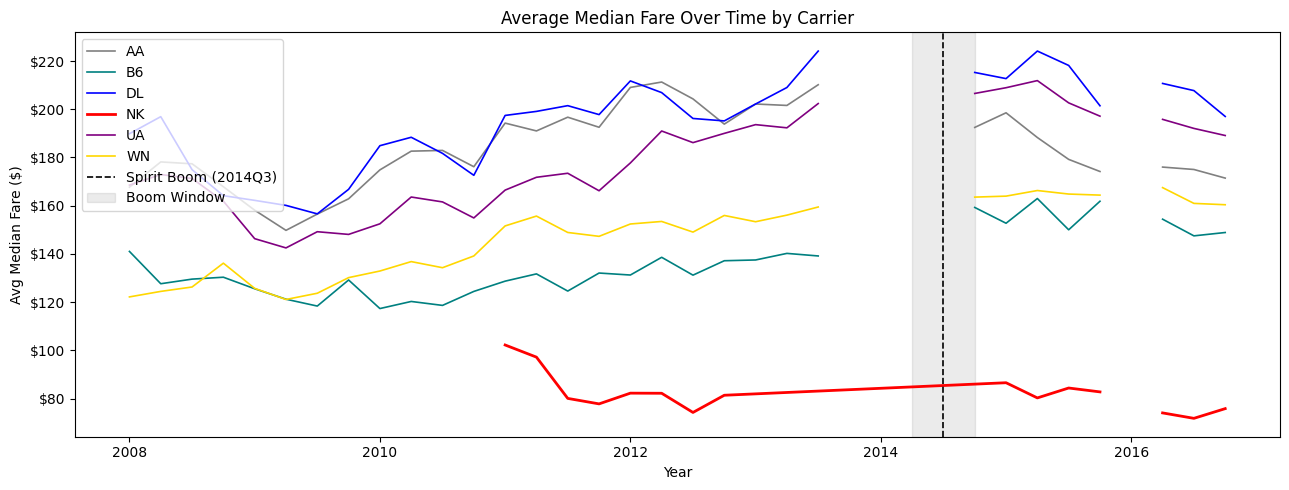

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Plot 1: Average median fare over time — Spirit vs legacy carriers ──
fare_trend = df_with_fares.filter(
    F.col("OpCarrier").isin(["NK", "DL", "AA", "WN", "UA", "B6"])
) \
.groupBy("Year", "Quarter", "OpCarrier") \
.agg(F.mean("median_fare").alias("avg_fare")) \
.orderBy("Year", "Quarter")

# Only .toPandas() at the very end for plotting
trend_pd = fare_trend.toPandas()
trend_pd["time"] = trend_pd["Year"] + (trend_pd["Quarter"] - 1) / 4

fig, ax = plt.subplots(figsize=(13, 5))
colors = {"NK": "red", "WN": "gold", "DL": "blue", "AA": "gray", "UA": "purple", "B6": "teal"}
for carrier, grp in trend_pd.groupby("OpCarrier"):
    ax.plot(grp["time"], grp["avg_fare"], label=carrier,
            color=colors.get(carrier), linewidth=2 if carrier == "NK" else 1.2)

ax.axvline(2014.5, color="black", linestyle="--", linewidth=1.2, label="Spirit Boom (2014Q3)")
ax.axvspan(2014.25, 2014.75, alpha=0.08, color="black", label="Boom Window")
ax.set(title="Average Median Fare Over Time by Carrier",
       xlabel="Year", ylabel="Avg Median Fare ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

26/03/12 04:42:10 ERROR Inbox: Ignoring errore 99:>                (0 + 0) / 13]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apach

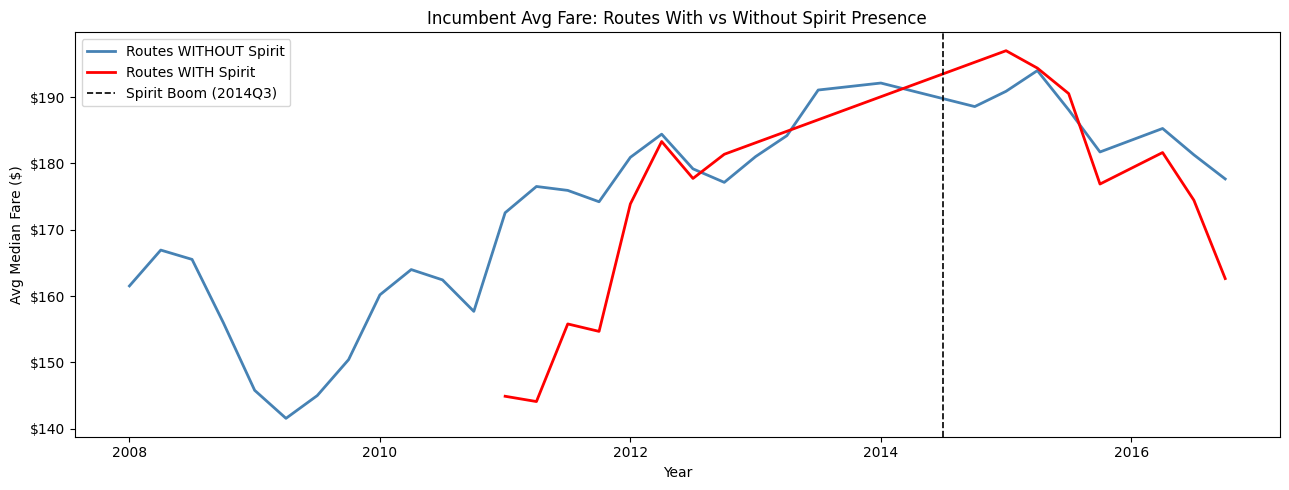

In [ ]:
# ── Plot 2: Incumbent fares on routes WITH vs WITHOUT Spirit ──

# PySpark: flag Spirit-present routes per quarter
spirit_presence = df_with_fares.filter(F.col("OpCarrier") == "NK") \
    .select("Year", "Quarter", "route").distinct() \
    .withColumn("spirit_present", F.lit(1))

# PySpark: join flag onto incumbents and aggregate
ulcc = ["NK", "F9", "G4", "SY"]
fare_by_spirit = df_with_fares \
    .filter(
        (~F.col("OpCarrier").isin(ulcc)) &
        (F.col("median_fare").isNotNull())
    ) \
    .join(spirit_presence, on=["Year", "Quarter", "route"], how="left") \
    .fillna({"spirit_present": 0}) \
    .groupBy("Year", "Quarter", "spirit_present") \
    .agg(F.mean("median_fare").alias("avg_fare")) \
    .orderBy("Year", "Quarter")

spirit_pd = fare_by_spirit.toPandas()
spirit_pd["time"] = spirit_pd["Year"] + (spirit_pd["Quarter"] - 1) / 4

fig, ax = plt.subplots(figsize=(13, 5))
for presence, grp in spirit_pd.groupby("spirit_present"):
    label = "Routes WITH Spirit" if presence == 1 else "Routes WITHOUT Spirit"
    color = "red" if presence == 1 else "steelblue"
    ax.plot(grp["time"], grp["avg_fare"], label=label, color=color, linewidth=2)

ax.axvline(2014.5, color="black", linestyle="--", linewidth=1.2, label="Spirit Boom (2014Q3)")
ax.set(title="Incumbent Avg Fare: Routes With vs Without Spirit Presence",
       xlabel="Year", ylabel="Avg Median Fare ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

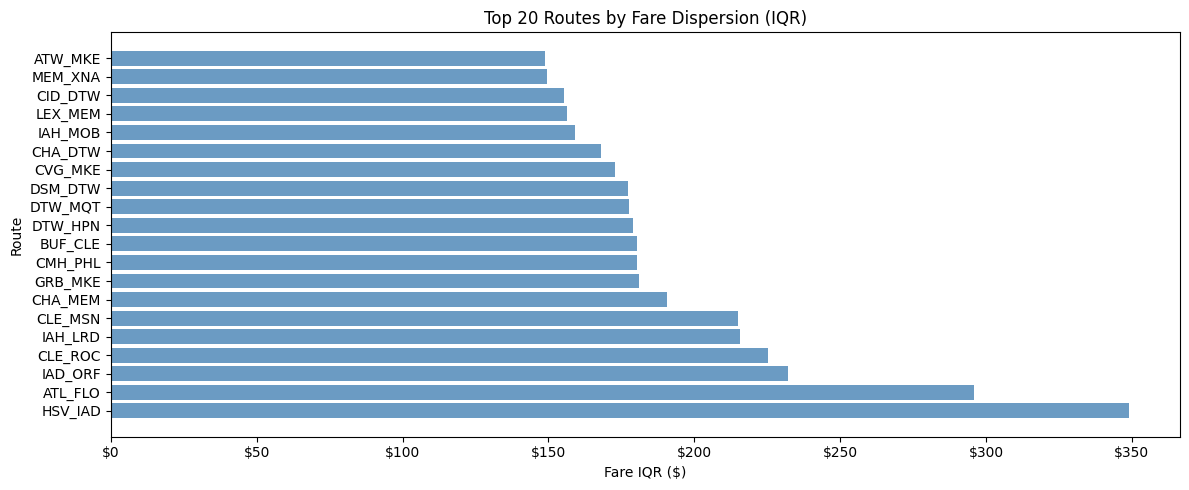

In [ ]:
# ── Plot 3: Route-level fare dispersion (price spread per route) ──

# PySpark: compute IQR per route as measure of fare dispersion
dispersion = df_with_fares \
    .filter(F.col("median_fare").isNotNull()) \
    .groupBy("route") \
    .agg(
        F.percentile_approx("median_fare", 0.75).alias("p75"),
        F.percentile_approx("median_fare", 0.25).alias("p25"),
        F.mean("median_fare").alias("avg_fare"),
        F.count("median_fare").alias("obs")
    ) \
    .withColumn("iqr", F.col("p75") - F.col("p25")) \
    .filter(F.col("obs") >= 10)  # remove thin routes

disp_pd = dispersion.orderBy("iqr", ascending=False).limit(20).toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(disp_pd["route"], disp_pd["iqr"], color="steelblue", alpha=0.8)
ax.set(title="Top 20 Routes by Fare Dispersion (IQR)",
       xlabel="Fare IQR ($)", ylabel="Route")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

# Regressions and ML

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, 
    VectorAssembler, StandardScaler
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# ── Step 1: Prepare base ML dataset in PySpark ──
ulcc = ["NK", "F9", "G4", "SY"]

spirit_fare = df_with_fares \
    .filter(F.col("OpCarrier") == "NK") \
    .groupBy("Year", "Quarter", "route") \
    .agg(F.mean("median_fare").alias("spirit_fare"))

ml_data = df_with_fares \
    .filter(
        (~F.col("OpCarrier").isin(ulcc)) &
        (F.col("median_fare").isNotNull()) &
        (F.col("HHI_10000").isNotNull()) &
        (F.col("carrier_share").isNotNull())
    ) \
    .groupBy("Year", "Quarter", "route", "OpCarrier") \
    .agg(
        F.mean("median_fare").alias("avg_fare"),
        F.first("HHI_10000").alias("HHI"),
        F.first("carrier_share").alias("carrier_share"),
        F.first("DistanceGroup").alias("dist_group")
    ) \
    .join(spirit_fare, on=["Year", "Quarter", "route"], how="left") \
    .withColumn("spirit_present", 
        F.when(F.col("spirit_fare").isNotNull(), 1).otherwise(0)) \
    .withColumn("shorthaul", 
        (F.col("dist_group") <= 2).cast("int")) \
    .dropna(subset=["avg_fare", "HHI", "carrier_share", "OpCarrier", "route"])

ml_data.cache()
print(f"ML dataset rows: {ml_data.count():,}")
ml_data.printSchema()

ML dataset rows: 49,759
root
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- route: string (nullable = true)
 |-- OpCarrier: string (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-- HHI: integer (nullable = true)
 |-- carrier_share: double (nullable = true)
 |-- dist_group: integer (nullable = true)
 |-- spirit_fare: double (nullable = true)
 |-- spirit_present: integer (nullable = false)
 |-- shorthaul: integer (nullable = true)



In [ ]:
# ── Step 2: String Indexing + One-Hot Encoding ──
# StringIndexer converts categorical strings to numeric indices
# OneHotEncoder then converts those indices to binary vectors
# This is the standard PySpark approach — never feed raw strings to a model

# Index categorical columns
carrier_indexer = StringIndexer(
    inputCol="OpCarrier",
    outputCol="carrier_idx",
    handleInvalid="keep"  # handles unseen carriers in test set
)

route_indexer = StringIndexer(
    inputCol="route",
    outputCol="route_idx",
    handleInvalid="keep"
)

# One-hot encode the indexed columns
carrier_encoder = OneHotEncoder(
    inputCol="carrier_idx",
    outputCol="carrier_ohe"
)

route_encoder = OneHotEncoder(
    inputCol="route_idx",
    outputCol="route_ohe"
)

print("Indexers and encoders defined successfully.")

Indexers and encoders defined successfully.


In [ ]:
# ── Step 3: Assemble all features into one vector ──
# VectorAssembler combines numeric cols + OHE vectors into single feature vector

assembler = VectorAssembler(
    inputCols=[
        "HHI",            # market concentration
        "carrier_share",  # incumbent's route share
        "spirit_present", # whether Spirit is on the route
        "shorthaul",      # route distance category
        "Year",           # time trend
        "Quarter",        # seasonality
        "carrier_ohe",    # one-hot encoded carrier
        "route_ohe"       # one-hot encoded route
    ],
    outputCol="raw_features",
    handleInvalid="keep"
)

# StandardScaler normalizes numeric features to mean=0, std=1
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=False,  # False because OHE vectors are sparse
    withStd=True
)

print("Assembler and scaler defined successfully.")

Assembler and scaler defined successfully.


## Model A: K-MEANS CLUSTERING

In [ ]:
# ══════════════════════════════════════════════
# MODEL A: K-MEANS CLUSTERING
# Segment routes by competitive structure
# ══════════════════════════════════════════════

# For clustering use route-level aggregates only — no need for OHE here
route_profiles = ml_data.groupBy("route") \
    .agg(
        F.mean("HHI").alias("avg_HHI"),
        F.mean("avg_fare").alias("avg_fare"),
        F.mean("carrier_share").alias("avg_carrier_share"),
        F.mean("spirit_present").alias("spirit_freq"),
        F.mean("shorthaul").alias("pct_shorthaul"),
        (F.mean("avg_fare") / F.mean("HHI")).alias("fare_per_hhi")
    ).dropna()

# Assemble features for clustering
cluster_assembler = VectorAssembler(
    inputCols=["avg_HHI", "avg_fare", "avg_carrier_share", 
               "spirit_freq", "pct_shorthaul"],
    outputCol="raw_features"
)

cluster_scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

# K-Means with k=4 (matches your proposal)
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=4,
    seed=42,
    maxIter=20
)

# Build clustering pipeline
cluster_pipeline = Pipeline(stages=[
    cluster_assembler,
    cluster_scaler,
    kmeans
])

# Fit on ALL route profiles (unsupervised — no train/test split needed)
cluster_model = cluster_pipeline.fit(route_profiles)
clustered_routes = cluster_model.transform(route_profiles)

print("=== K-Means Cluster Sizes ===")
clustered_routes.groupBy("cluster").count().orderBy("cluster").show()

print("=== Cluster Profiles ===")
clustered_routes.groupBy("cluster").agg(
    F.mean("avg_HHI").alias("avg_HHI"),
    F.mean("avg_fare").alias("avg_fare"),
    F.mean("spirit_freq").alias("spirit_freq"),
    F.mean("pct_shorthaul").alias("pct_shorthaul"),
    F.count("route").alias("n_routes")
).orderBy("cluster").show()

26/03/11 22:35:17 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/11 22:35:17 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


=== K-Means Cluster Sizes ===
+-------+-----+
|cluster|count|
+-------+-----+
|      0|  636|
|      1|   29|
|      2|  366|
|      3|  511|
+-------+-----+

=== Cluster Profiles ===
+-------+------------------+------------------+--------------------+-------------+--------+
|cluster|           avg_HHI|          avg_fare|         spirit_freq|pct_shorthaul|n_routes|
+-------+------------------+------------------+--------------------+-------------+--------+
|      0|5227.6751554251505| 173.7874285013389|0.004848659455390484|          1.0|     636|
|      1| 5406.288100307649|162.91043287767877| 0.42687522242663356|          1.0|      29|
|      2| 6043.242839737496|276.99012810357124|0.001143226571805...|          1.0|     366|
|      3| 9326.258520789532|170.47126850891027|0.001955844618265...|          1.0|     511|
+-------+------------------+------------------+--------------------+-------------+--------+



k=2: cost=3945.01
k=3: cost=3174.12
k=4: cost=2066.35
k=5: cost=1806.42
k=6: cost=1596.54
k=7: cost=1328.15


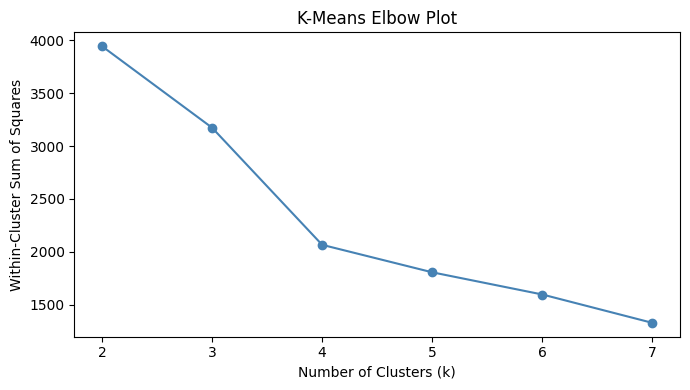

In [ ]:
# ── Elbow plot to justify k=4 ──
costs = []
for k in range(2, 8):
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    pipe = Pipeline(stages=[cluster_assembler, cluster_scaler, km])
    fitted = pipe.fit(route_profiles)
    cost = fitted.stages[-1].summary.trainingCost
    costs.append((k, cost))
    print(f"k={k}: cost={cost:.2f}")

cost_pd = pd.DataFrame(costs, columns=["k", "cost"])
plt.figure(figsize=(7, 4))
plt.plot(cost_pd["k"], cost_pd["cost"], marker="o", color="steelblue")
plt.title("K-Means Elbow Plot")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.tight_layout()
plt.show()

## Model B: GRADIENT BOOSTED TREES

In [ ]:
# ══════════════════════════════════════════════
# MODEL B: GRADIENT BOOSTED TREES (GBT)
# Predict incumbent fare from market features
# ══════════════════════════════════════════════

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# ── Step 1: Prepare clean ML dataset ──
ulcc = ["NK", "F9", "G4", "SY"]

spirit_fare = df_with_fares \
    .filter(F.col("OpCarrier") == "NK") \
    .groupBy("Year", "Quarter", "route") \
    .agg(F.mean("median_fare").alias("spirit_fare"))

ml_data = df_with_fares \
    .filter(
        (~F.col("OpCarrier").isin(ulcc)) &
        (F.col("median_fare").isNotNull()) &
        (F.col("HHI_10000").isNotNull()) &
        (F.col("carrier_share").isNotNull())
    ) \
    .groupBy("Year", "Quarter", "route", "OpCarrier") \
    .agg(
        F.mean("median_fare").alias("avg_fare"),
        F.first("HHI_10000").alias("HHI"),
        F.first("carrier_share").alias("carrier_share"),
        F.first("DistanceGroup").alias("dist_group")
    ) \
    .join(spirit_fare, on=["Year", "Quarter", "route"], how="left") \
    .withColumn("spirit_present",
        F.when(F.col("spirit_fare").isNotNull(), 1).otherwise(0)) \
    .withColumn("shorthaul",
        (F.col("dist_group") <= 2).cast("int")) \
    .dropna(subset=["avg_fare", "HHI", "carrier_share", "OpCarrier", "route"])

ml_data.cache()
print(f"Total rows: {ml_data.count():,}")
ml_data.printSchema()

26/03/11 22:58:53 WARN CacheManager: Asked to cache already cached data.


Total rows: 49,759
root
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- route: string (nullable = true)
 |-- OpCarrier: string (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-- HHI: integer (nullable = true)
 |-- carrier_share: double (nullable = true)
 |-- dist_group: integer (nullable = true)
 |-- spirit_fare: double (nullable = true)
 |-- spirit_present: integer (nullable = false)
 |-- shorthaul: integer (nullable = true)



In [ ]:
# ── Step 2: 80/20 random train/test split ──
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)

print(f"Train rows: {train_data.count():,}")
print(f"Test rows:  {test_data.count():,}")

Train rows: 39,761
Test rows:  9,998


In [ ]:
# ── Step 3: StringIndexer — convert strings to numeric index ──
carrier_indexer = StringIndexer(
    inputCol="OpCarrier",
    outputCol="carrier_idx",
    handleInvalid="keep"
)

route_indexer = StringIndexer(
    inputCol="route",
    outputCol="route_idx",
    handleInvalid="keep"
)

# ── Step 4: OneHotEncoder — convert index to binary vector ──
carrier_encoder = OneHotEncoder(
    inputCol="carrier_idx",
    outputCol="carrier_ohe"
)

route_encoder = OneHotEncoder(
    inputCol="route_idx",
    outputCol="route_ohe"
)

# ── Step 5: VectorAssembler — combine all features into one vector ──
# No time FE — Year and Quarter dropped
assembler = VectorAssembler(
    inputCols=[
        "HHI",            # market concentration
        "carrier_share",  # incumbent route share
        "spirit_present", # Spirit on route (0/1)
        "shorthaul",      # distance category (0/1)
        "spirit_fare",    # Spirit's actual fare (fill 0 if absent)
        "carrier_ohe",    # one-hot encoded carrier
    ],
    outputCol="raw_features",
    handleInvalid="keep"
)

# ── Step 6: StandardScaler ──
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=False,   # False because sparse OHE vectors
    withStd=True
)

print("Pipeline stages defined successfully.")

Pipeline stages defined successfully.


In [ ]:
# ── Step 7: Fill null spirit_fare with 0 before pipeline ──
# Routes without Spirit get spirit_fare = 0
train_data = train_data.fillna({"spirit_fare": 0.0})
test_data  = test_data.fillna({"spirit_fare": 0.0})

In [ ]:
# ── Step 8: GBT Model ──
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="avg_fare",
    maxIter=100,
    maxDepth=5,
    stepSize=0.05,
    seed=42
)

# ── Step 9: Build full pipeline ──
pipeline = Pipeline(stages=[
    carrier_indexer,
    route_indexer,
    carrier_encoder,
    route_encoder,
    assembler,
    scaler,
    gbt
])

print("Training GBT model...")
gbt_model = pipeline.fit(train_data)
print("Training completed successfully.")

Training GBT model...


Training complete ✓


In [ ]:
# ── Step 10: Evaluate on test set ──
predictions = gbt_model.transform(test_data)

evaluator_rmse = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="r2")
evaluator_mae  = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)
mae  = evaluator_mae.evaluate(predictions)

print("=" * 40)
print("GBT TEST SET RESULTS")
print("=" * 40)
print(f"RMSE: ${rmse:.2f}")
print(f"MAE:  ${mae:.2f}")
print(f"R-squared :   {r2:.4f}")

GBT TEST SET RESULTS
RMSE: $58.91
MAE:  $43.40
R-squared :   0.2660


OSError: [Errno 30] Read-only file system: 'gbt_feature_importance.png'

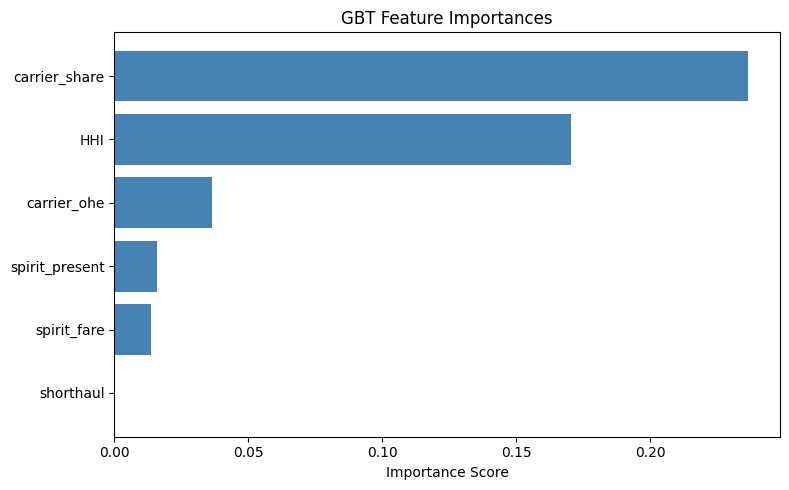

In [ ]:
# ── Step 11: Feature importance ──
feature_names = [
    "HHI", "carrier_share", "spirit_present",
    "shorthaul", "spirit_fare", "carrier_ohe"
]

importances = gbt_model.stages[-1].featureImportances
importance_pd = pd.DataFrame({
    "feature": feature_names,
    "importance": [importances[i] for i in range(len(feature_names))]
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_pd["feature"], importance_pd["importance"], color="steelblue")
plt.title("GBT Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Sample size: 3,088
Unique predictions: 708


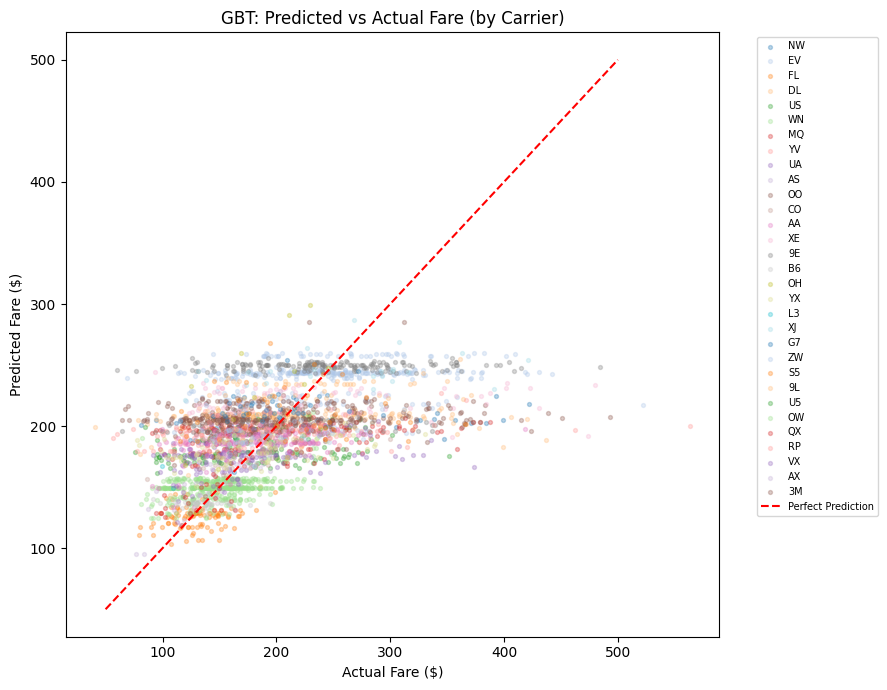

In [ ]:
# ── Step 12: Predicted vs Actual ──
pred_pd = predictions.select(
    "avg_fare", "prediction", "OpCarrier"
).sample(fraction=0.3, seed=42).toPandas()

print(f"Sample size: {len(pred_pd):,}")
print(f"Unique predictions: {pred_pd['prediction'].round(1).nunique()}")

fig, ax = plt.subplots(figsize=(9, 7))
plot_colors = plt.cm.tab20.colors
for i, carrier in enumerate(pred_pd["OpCarrier"].unique()):
    sub = pred_pd[pred_pd["OpCarrier"] == carrier]
    ax.scatter(sub["avg_fare"], sub["prediction"],
               alpha=0.3, s=8,
               color=plot_colors[i % len(plot_colors)],
               label=carrier)

ax.plot([50, 500], [50, 500], "r--", linewidth=1.5, label="Perfect Prediction")
ax.set(title="GBT: Predicted vs Actual Fare (by Carrier)",
       xlabel="Actual Fare ($)", ylabel="Predicted Fare ($)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Check target distribution in PySpark
ml_data.select(
    F.min("avg_fare").alias("min"),
    F.percentile_approx("avg_fare", 0.25).alias("p25"),
    F.percentile_approx("avg_fare", 0.5).alias("median"),
    F.percentile_approx("avg_fare", 0.75).alias("p75"),
    F.percentile_approx("avg_fare", 0.90).alias("p90"),
    F.max("avg_fare").alias("max"),
    F.count("avg_fare").alias("n")
).show()

# Check how many obs fall in each fare bucket
ml_data.withColumn("fare_bucket",
    F.when(F.col("avg_fare") < 150, "under_150")
     .when(F.col("avg_fare") < 250, "150_250")
     .when(F.col("avg_fare") < 350, "250_350")
     .otherwise("over_350")
).groupBy("fare_bucket").count().orderBy("fare_bucket").show()

+----+-----+-----------------+-----------------+-----+-----+-----+
| min|  p25|           median|              p75|  p90|  max|    n|
+----+-----+-----------------+-----------------+-----+-----+-----+
|26.0|144.5|179.3800000000037|230.9900000000001|289.5|866.0|49759|
+----+-----+-----------------+-----------------+-----+-----+-----+

+-----------+-----+
|fare_bucket|count|
+-----------+-----+
|    150_250|26001|
|    250_350| 7665|
|   over_350| 1680|
|  under_150|14413|
+-----------+-----+



In [ ]:
# ── Stratified sampling by fare bucket to balance target ──
# Undersample the dominant middle bucket, keep all rare high/low fares

ml_data_bucketed = ml_data.withColumn("fare_bucket",
    F.when(F.col("avg_fare") < 150, "under_150")
     .when(F.col("avg_fare") < 250, "150_250")
     .when(F.col("avg_fare") < 350, "250_350")
     .otherwise("over_350")
)

# Check counts per bucket first
bucket_counts = ml_data_bucketed.groupBy("fare_bucket") \
    .count().orderBy("fare_bucket")
bucket_counts.show()

+-----------+-----+
|fare_bucket|count|
+-----------+-----+
|    150_250|26001|
|    250_350| 7665|
|   over_350| 1680|
|  under_150|14413|
+-----------+-----+



In [ ]:
# Sample fractions — cap the dominant bucket at ~15k
# Keep rarer buckets at 100% to preserve high/low fare observations
fractions = {
    "under_150": 1.0,    # keep all — underrepresented
    "150_250":   0.3,    # downsample dominant middle
    "250_350":   1.0,    # keep all
    "over_350":  1.0     # keep all — underrepresented
}

ml_balanced = ml_data_bucketed.sampleBy(
    "fare_bucket", fractions=fractions, seed=42
).drop("fare_bucket")

print(f"Original rows: {ml_data.count():,}")
print(f"Balanced rows: {ml_balanced.count():,}")

# Verify new distribution
ml_balanced.select(
    F.percentile_approx("avg_fare", [0.25, 0.5, 0.75, 0.9]).alias("percentiles")
).show()

Original rows: 49,759
Balanced rows: 31,579
+--------------------+
|         percentiles|
+--------------------+
|[130.5, 161.99, 2...|
+--------------------+



In [ ]:
# ── 80/20 split on balanced data ──
train_bal, test_bal = ml_balanced.randomSplit([0.8, 0.2], seed=42)
train_bal = train_bal.fillna({"spirit_fare": 0.0})
test_bal  = test_bal.fillna({"spirit_fare": 0.0})

print(f"Balanced train: {train_bal.count():,}")
print(f"Balanced test:  {test_bal.count():,}")

# ── Retrain same pipeline ──
print("Training balanced GBT...")
gbt_model_bal = pipeline.fit(train_bal)
print("Done")

Balanced train: 25,296
Balanced test:  6,283
Training balanced GBT...


Done


In [ ]:
# ── Evaluate ──
predictions_bal = gbt_model_bal.transform(test_bal)

rmse_bal = evaluator_rmse.evaluate(predictions_bal)
r2_bal   = evaluator_r2.evaluate(predictions_bal)
mae_bal  = evaluator_mae.evaluate(predictions_bal)

print("=" * 45)
print("GBT BALANCED (fare distribution) RESULTS")
print("=" * 45)
print(f"RMSE: ${rmse_bal:.2f}  (was ${rmse:.2f})")
print(f"MAE:  ${mae_bal:.2f}  (was ${mae:.2f})")
print(f"R-squared:   {r2_bal:.4f}  (was {r2:.4f})")

GBT BALANCED (fare distribution) RESULTS
RMSE: $68.91  (was $58.91)
MAE:  $51.95  (was $43.40)
R-squared:   0.3313  (was 0.2660)


# Regressions

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.sql import Window

# ── Data Prep ──
ulcc = ["NK", "F9", "G4", "SY"]

spirit_fare_reg = df_with_fares \
    .filter(F.col("OpCarrier") == "NK") \
    .groupBy("Year", "Quarter", "route") \
    .agg(F.mean("median_fare").alias("spirit_fare"))

panel = df_with_fares \
    .filter(
        (~F.col("OpCarrier").isin(ulcc)) &
        (F.col("median_fare").isNotNull()) &
        (F.col("HHI_10000").isNotNull()) &
        (F.col("carrier_share").isNotNull())
    ) \
    .groupBy("Year", "Quarter", "route", "OpCarrier") \
    .agg(
        F.mean("median_fare").alias("avg_fare"),
        F.first("HHI_10000").alias("HHI"),
        F.first("carrier_share").alias("carrier_share"),
        F.first("DistanceGroup").alias("dist_group")
    ) \
    .join(spirit_fare_reg, on=["Year", "Quarter", "route"], how="left") \
    .withColumn("spirit_present",
        F.when(F.col("spirit_fare").isNotNull(), 1).otherwise(0)) \
    .withColumn("shorthaul", (F.col("dist_group") <= 2).cast("int")) \
    .withColumn("time_idx", F.col("Year") * 4 + F.col("Quarter")) \
    .fillna({"spirit_fare": 0.0})

# Lagged spirit fare
window_spec = Window.partitionBy("route", "OpCarrier").orderBy("time_idx")
panel = panel.withColumn("spirit_fare_lag", F.lag("spirit_fare", 1).over(window_spec))

# Spirit route flag
spirit_routes_df = df_with_fares \
    .filter(F.col("OpCarrier") == "NK") \
    .select("route").distinct() \
    .withColumn("spirit_route", F.lit(1))

panel = panel \
    .join(spirit_routes_df, on="route", how="left") \
    .fillna({"spirit_route": 0}) \
    .dropna(subset=["avg_fare", "HHI", "carrier_share", "spirit_fare_lag"])

panel.cache()
print(f"Panel rows: {panel.count():,}")

In [ ]:
# ── Pipeline ──
pipeline_lr = Pipeline(stages=[
    StringIndexer(inputCol="route",     outputCol="route_idx",   handleInvalid="keep"),
    StringIndexer(inputCol="OpCarrier", outputCol="carrier_idx", handleInvalid="keep"),
    OneHotEncoder(inputCol="route_idx",    outputCol="route_ohe"),
    OneHotEncoder(inputCol="carrier_idx",  outputCol="carrier_ohe"),
    VectorAssembler(
        inputCols=["spirit_fare_lag", "HHI", "carrier_share",
                   "spirit_present", "shorthaul", "carrier_ohe", "route_ohe"],
        outputCol="raw_features", handleInvalid="keep"
    ),
    StandardScaler(inputCol="raw_features", outputCol="features",
                   withMean=False, withStd=True),
    LinearRegression(featuresCol="features", labelCol="avg_fare",
                     maxIter=100, regParam=0.0, elasticNetParam=0.0)
])

In [ ]:
# ── Train & Evaluate all 3 models ──
evaluator_rmse = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="r2")
evaluator_mae  = RegressionEvaluator(labelCol="avg_fare", predictionCol="prediction", metricName="mae")

def run_model(name, train, test):
    model = pipeline_lr.fit(train)
    preds = model.transform(test)
    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"RMSE: ${evaluator_rmse.evaluate(preds):.2f}")
    print(f"MAE:  ${evaluator_mae.evaluate(preds):.2f}")
    print(f"R²:   {evaluator_r2.evaluate(preds):.4f}")

    # Key coefficients
    coefs = model.stages[-1].coefficients
    labels = ["spirit_fare_lag", "HHI", "carrier_share", "spirit_present", "shorthaul"]
    print("\nKey Coefficients:")
    for i, label in enumerate(labels):
        print(f"  {label:20s}: {coefs[i]:+.4f}")
    return model

train, test = panel.randomSplit([0.8, 0.2], seed=42)

# Model 1: All routes
m1 = run_model("MODEL 1: Baseline (All Routes)", train, test)

# Model 2: Shorthaul only
m2 = run_model("MODEL 2: Shorthaul Only",
               train.filter(F.col("shorthaul") == 1),
               test.filter(F.col("shorthaul") == 1))

# Model 3: Spirit-present routes
m3 = run_model("MODEL 3: Spirit-Present Routes",
               train.filter(F.col("spirit_route") == 1),
               test.filter(F.col("spirit_route") == 1))